In [1]:
#Loading libraries
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(purrr)
library(readr)

Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”


In [2]:
#Loading tables
master <- read.delim("arch_cluster_master.tsv",header = FALSE,stringsAsFactors = FALSE)
colnames(master) <- c("cluster",
  "protein",
  "genome",
  "contig",
  "replicon")

annot <- read.delim("arch_cluster_annotation.tsv",stringsAsFactors = FALSE)

#Merge annotations
dat <- master %>%
  filter(replicon %in% c("chr1","chr2plus","plasmid")) %>%
  left_join(annot %>%
      select(cluster, COG_category),by = "cluster")

In [3]:
#Calculating relative abundance
#Expand multi-letter COG assignments
cog <- dat %>%
  filter(!is.na(COG_category),
         COG_category != "") %>%
  mutate(COG_category = strsplit(COG_category, ""),
    weight = lapply(COG_category,
                    function(x) 1/length(x))) %>%
  unnest(c(COG_category, weight))

#Relative abundance
cog_rel <- cog %>%
  group_by(replicon, COG_category) %>%
  summarise(N = sum(weight),.groups = "drop") %>%
  group_by(replicon) %>%
  mutate(Fraction = N/sum(N)) %>%
  ungroup()

In [4]:
#Constructing COG counts table including S and -
#One occurrence of each cluster per replicon type
cluster_dat <- master %>%
  filter(replicon %in% c("chr1", "chr2plus", "plasmid")) %>%
  distinct(replicon, cluster) %>%
  left_join(annot %>%
      select(cluster, COG_category),
    by = "cluster")

#Expand multi-letter COG categories
#Keep S and "-" in the analysis
cluster_dat <- cluster_dat %>%
  filter(!is.na(COG_category),
    COG_category != "") %>%
  mutate(COG_category = strsplit(COG_category, ""),
    weight = lapply(COG_category,
      function(x) 1 / length(x))) %>%
  unnest(c(COG_category, weight))

#Relative abundance of COG categories
#Based on distinct clusters per replicon
cluster_rel <- cluster_dat %>%
  group_by(replicon, COG_category) %>%
  summarise(N = sum(weight),
    .groups = "drop") %>%
  group_by(replicon) %>%
  mutate(Fraction = N / sum(N)) %>%
  ungroup()

#Weighted number of proteins per COG category
#Based on the original protein-level data (cog)
gene_counts <- cog %>%
  filter(!is.na(COG_category),
    COG_category != "") %>%
  group_by(replicon, COG_category) %>%
  summarise(Weighted_genes = sum(weight),
    .groups = "drop")


#Combine fraction + weighted gene count
table_cog <- cluster_rel %>%
  mutate(Fraction = round(Fraction * 100, 2)) %>%
  select(COG_category,
    replicon,
    Fraction) %>%
  left_join(
    gene_counts,
    by = c("COG_category", "replicon")) %>%
  pivot_wider(names_from = replicon,
    values_from = c(Fraction, Weighted_genes),
    names_glue = "{replicon}_{.value}")

table_cog 
                    
#Write table
write.table(table_cog, "./paper/all_COG_cluster_rel_ab.tsv", sep = "\t", quote = FALSE, row.names = FALSE)

COG_category,chr1_Fraction,chr2plus_Fraction,plasmid_Fraction,chr1_Weighted_genes,chr2plus_Weighted_genes,plasmid_Weighted_genes
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-,26.63,18.65,22.92,111561.00,1192.00000,18557.000
A,0.02,0.02,0.01,34.00,1.00000,8.000
B,0.02,0.02,0.00,136.00,1.00000,4.500
C,4.12,5.41,3.83,40810.00,383.50000,5171.000
D,0.67,0.85,0.57,5599.50,70.50000,1239.500
E,4.39,6.52,6.03,54987.33,535.33333,7600.833
F,1.15,2.02,1.05,16840.50,126.50000,936.500
G,2.92,5.24,4.17,20533.83,339.33333,4204.333
H,2.42,2.84,1.94,29753.00,194.50000,2164.500


In [5]:
#Merging with FANTASIA

In [6]:
#Consensus GO annotation from FANTASIA for the entire dataset
#Loading tables
master <- read.delim(
    "arch_cluster_master_gc_NEW.tsv",
    header = FALSE,
    stringsAsFactors = FALSE)

colnames(master) <- c("cluster",
    "protein",        # Prokka protein ID
    "genome",
    "contig",
    "replicon",
    "prodigal_id",    # Original Prodigal ID (used by FANTASIA)
    "gc_cont")

annot <- read.delim("arch_cluster_annotation.tsv",
    stringsAsFactors = FALSE)

go <- read.delim("fantasia/fantasia_GO_annotations.tsv",
    stringsAsFactors = FALSE)

In [20]:
#Creating hm with the general FANTASIA annotation
master %>%
  inner_join(go, by = c("prodigal_id" = "protein")) %>%
  count(ontology)

go_cluster <- master %>%
  select(cluster, prodigal_id) %>%
  inner_join(go, by = c("prodigal_id" = "protein")) %>%
  distinct(cluster, ontology, GO, name)

top_go <- go_cluster %>%
  count(ontology, GO, name, name = "clusters") %>%
  group_by(ontology) %>%
  slice_max(clusters, n = 15, with_ties = FALSE) %>%
  arrange(ontology, desc(clusters)) %>%
  ungroup()

#Loading libraries
library(tibble) 
library(pheatmap)

# Función para preparar cada ontología
make_go_matrix <- function(ont) {
  
  terms <- top_go %>%
    filter(ontology == ont) %>%
    pull(GO)
  
  mat <- go_cluster %>%
    filter(ontology == ont, GO %in% terms) %>%
    mutate(value = 1) %>%
    select(GO, cluster, value) %>%
    tidyr::pivot_wider(
      names_from = cluster,
      values_from = value,
      values_fill = 0
    )
  
  mat <- as.matrix(mat[, -1])
  rownames(mat) <- mat[, 1]
  
  mat <- mat[, -1, drop = FALSE]
  
  # perfiles funcionales únicos
  mat <- unique(t(mat))
  mat <- t(mat)
  
  return(mat)
}

bp_mat <- make_go_matrix("BP")
cc_mat <- make_go_matrix("CC")
mf_mat <- make_go_matrix("MF")

dim(bp_mat)
dim(cc_mat)
dim(mf_mat)

sort(unique(master$replicon))

ontology,n
<chr>,<int>
BP,1442105
CC,1348368
MF,1542693


[1]  15 587

[1]   15 1195

[1]   15 1384

[1] "chr1"     "chr2plus" "plasmid"

Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `Total_replicon = n_distinct(master$cluster[master$replicon == replicon])`.
ℹ In group 1: `replicon = "chr1"`.
Caused by warning in `master$replicon == replicon`:
! longer object length is not a multiple of shorter object length
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”
Saving 20 x 6.67 in image


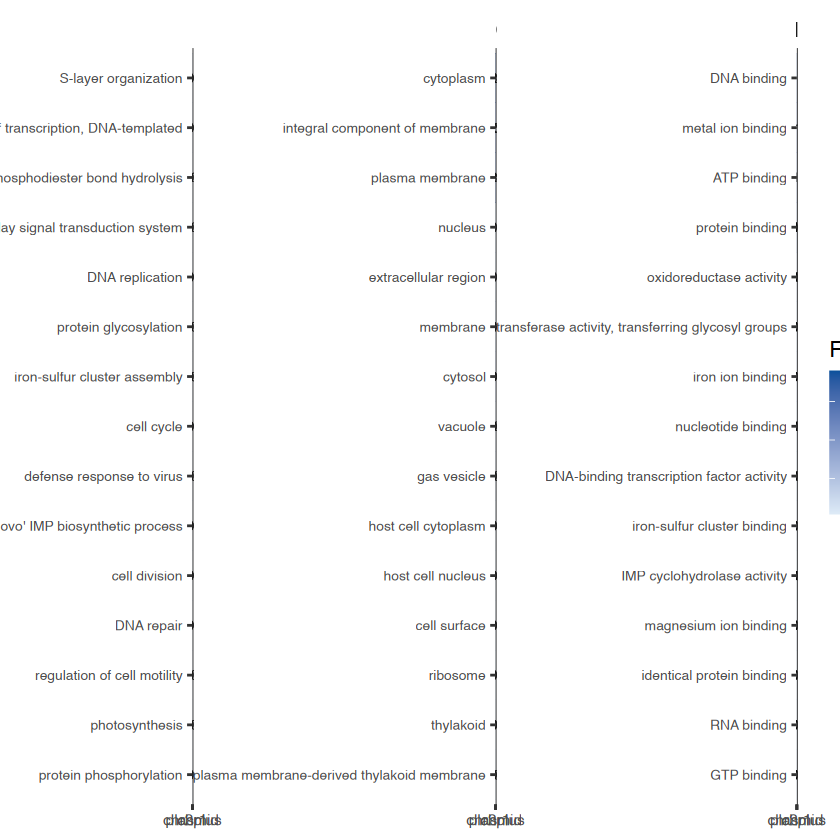

In [28]:
plot_dat <- master %>%
  select(cluster, replicon, prodigal_id) %>%
  distinct() %>%
  inner_join(
    go %>% select(protein, GO, ontology, name),
    by = c("prodigal_id" = "protein")
  ) %>%
  distinct(cluster, replicon, ontology, GO, name) %>%
  
  # exactamente los top 15 que ya calculamos
  inner_join(
    top_go %>% select(ontology, GO, name),
    by = c("ontology", "GO", "name")
  ) %>%
  
  group_by(replicon, ontology, GO, name) %>%
  summarise(
    Clusters = n_distinct(cluster),
    .groups = "drop"
  ) %>%
  
  # crear TODAS las combinaciones GO × replicon
  tidyr::complete(
    nesting(ontology, GO, name),
    replicon = c("chr1", "chr2plus", "plasmid"),
    fill = list(Clusters = 0)
  ) %>%
  
  # total de clusters de cada replicon
  group_by(replicon) %>%
  mutate(
    Total_replicon = n_distinct(
      master$cluster[master$replicon == replicon]
    ),
    Fraction = Clusters / Total_replicon
  ) %>%
  ungroup()

ggplot(
  plot_dat,
  aes(
    x = replicon,
    y = fct_reorder(name, Clusters),
    fill = Fraction
  )
) +
  geom_tile(colour = "white") +
  geom_text(
  aes(label = paste0(round(Fraction, 3))),
  size = 2.8,
  colour = "black"
)+
  facet_wrap(
    ~ontology,
    nrow = 1,
    scales = "free_y"
  ) +
  scale_x_discrete(
    limits = c("chr1", "chr2plus", "plasmid")
  ) +
  scale_fill_gradient(
    low = "#deebf7",
    high = "#08519c",
    name = "Fraction"
  ) +
  theme_bw(base_size = 13) +
  labs(
    x = NULL,
    y = NULL
  ) +
  theme(
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(size = 9),
    panel.grid = element_blank(),
    strip.background = element_blank(),
    strip.text = element_text(
      face = "bold",
      size = 12
    )
  )

ggsave("./paper/all_prot_top15_fantasia.svg", width=20)

In [6]:
#Selecting S and non-annotated COG clusters and chekcing the annotation in FANTASIA
unknown <- annot %>%
    filter(COG_category %in% c("S", "-")) %>%
    select(cluster, representative, COG_category)

#Retrieve GO annotations
cluster_go <- master %>%
    inner_join(unknown,
        by = "cluster") %>%
    left_join(go,
        by = c("prodigal_id" = "protein",
            "genome"))

#Consensus GO table
cluster_summary <- cluster_go %>%
    filter(!is.na(GO)) %>%
    group_by(cluster,
        representative,
        COG_category,
        ontology,
        GO,
        name) %>%
    summarise(Nproteins = n_distinct(prodigal_id),
        .groups = "drop") %>%
    group_by(cluster) %>%
    mutate(TotalProteins = sum(Nproteins),
        Fraction = Nproteins / TotalProteins) %>%
    arrange(cluster,
        desc(Nproteins)) %>%
    ungroup()

write.table(cluster_summary,"./figures/Unknown_cluster_GO_summary.tsv",sep = "\t",quote = FALSE,row.names = FALSE)
head(cluster_summary)

cluster,representative,COG_category,ontology,GO,name,Nproteins,TotalProteins,Fraction
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
AAFHMIJB_00153,AAFHMIJB_00153,-,BP,GO:0016226,iron-sulfur cluster assembly,9,36,0.2500000
AAFHMIJB_00153,AAFHMIJB_00153,-,CC,GO:0005886,plasma membrane,9,36,0.2500000
AAFHMIJB_00153,AAFHMIJB_00153,-,MF,GO:0005506,iron ion binding,9,36,0.2500000
AAFHMIJB_00153,AAFHMIJB_00153,-,MF,GO:0051536,iron-sulfur cluster binding,9,36,0.2500000
AAFHMIJB_00208,AAFHMIJB_00208,-,BP,GO:0009399,nitrogen fixation,14,66,0.2121212
AAFHMIJB_00208,AAFHMIJB_00208,-,CC,GO:0005829,cytosol,14,66,0.2121212


In [7]:
#Consensus GO annotation of unknown clusters
#Loading tables
master <- read.delim("arch_cluster_master_gc_NEW.tsv",
    header = FALSE,
    stringsAsFactors = FALSE)

colnames(master) <- c("cluster",
    "protein",
    "genome",
    "contig",
    "replicon",
    "prodigal_id",
    "gc_cont")

annot <- read.delim("arch_cluster_annotation.tsv",
    stringsAsFactors = FALSE)

go <- read.delim("fantasia/fantasia_GO_annotations.tsv",
    stringsAsFactors = FALSE)

#Unknown clusters
unknown <- annot %>%
    filter(COG_category %in% c("S","-")) %>%
    select(cluster,representative,
           COG_category)

#Join
cluster_go <- master %>%
    inner_join(unknown,
        by="cluster") %>%
    left_join(go, by=c("prodigal_id"="protein",
            "genome")) %>%
    filter(!is.na(name))

#Number of proteins per cluster × replicon
cluster_size <- cluster_go %>%
    distinct(cluster,
        replicon,
        prodigal_id) %>%
    count(cluster,
        replicon,
        name="ClusterProteins")

#GO support
cluster_table <- cluster_go %>%
    group_by(cluster,
        representative,
        COG_category,
        replicon,
        ontology,
        GO,
        name) %>%
    summarise(Nproteins=n_distinct(prodigal_id),
        .groups="drop") %>%
    left_join(cluster_size,
        by=c("cluster",
            "replicon") ) %>%
    mutate(Support=100*Nproteins/ClusterProteins) %>%
    arrange(cluster,
        replicon,
        ontology,
        desc(Support),
        desc(Nproteins))

write.table(cluster_table,"./paper/Unknown_cluster_GO_table.tsv", sep="\t",quote=FALSE,row.names=FALSE)
head(cluster_table)
#Consensus annotation
cluster_consensus <- cluster_table %>%
    group_by(cluster,
        replicon,
        ontology) %>%
    slice_max(order_by=Support,
        n=1,
        with_ties=FALSE) %>%
    ungroup()

write.table(cluster_consensus,"./paper/Unknown_cluster_consensus.tsv",sep="\t", quote=FALSE, row.names=FALSE)
head(cluster_consensus)

cluster,representative,COG_category,replicon,ontology,GO,name,Nproteins,ClusterProteins,Support
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,BP,GO:0016226,iron-sulfur cluster assembly,9,9,100
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,CC,GO:0005886,plasma membrane,9,9,100
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,MF,GO:0005506,iron ion binding,9,9,100
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,MF,GO:0051536,iron-sulfur cluster binding,9,9,100
AAFHMIJB_00208,AAFHMIJB_00208,-,chr1,BP,GO:0009399,nitrogen fixation,14,14,100
AAFHMIJB_00208,AAFHMIJB_00208,-,chr1,CC,GO:0005829,cytosol,14,14,100


cluster,representative,COG_category,replicon,ontology,GO,name,Nproteins,ClusterProteins,Support
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,BP,GO:0016226,iron-sulfur cluster assembly,9,9,100.00000
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,CC,GO:0005886,plasma membrane,9,9,100.00000
AAFHMIJB_00153,AAFHMIJB_00153,-,chr1,MF,GO:0005506,iron ion binding,9,9,100.00000
AAFHMIJB_00208,AAFHMIJB_00208,-,chr1,BP,GO:0009399,nitrogen fixation,14,14,100.00000
AAFHMIJB_00208,AAFHMIJB_00208,-,chr1,CC,GO:0005829,cytosol,14,14,100.00000
AAFHMIJB_00208,AAFHMIJB_00208,-,chr1,MF,GO:0016655,"oxidoreductase activity, acting on NAD(P)H, quinone or similar compound as acceptor",11,14,78.57143


Saving 20 x 6.67 in image


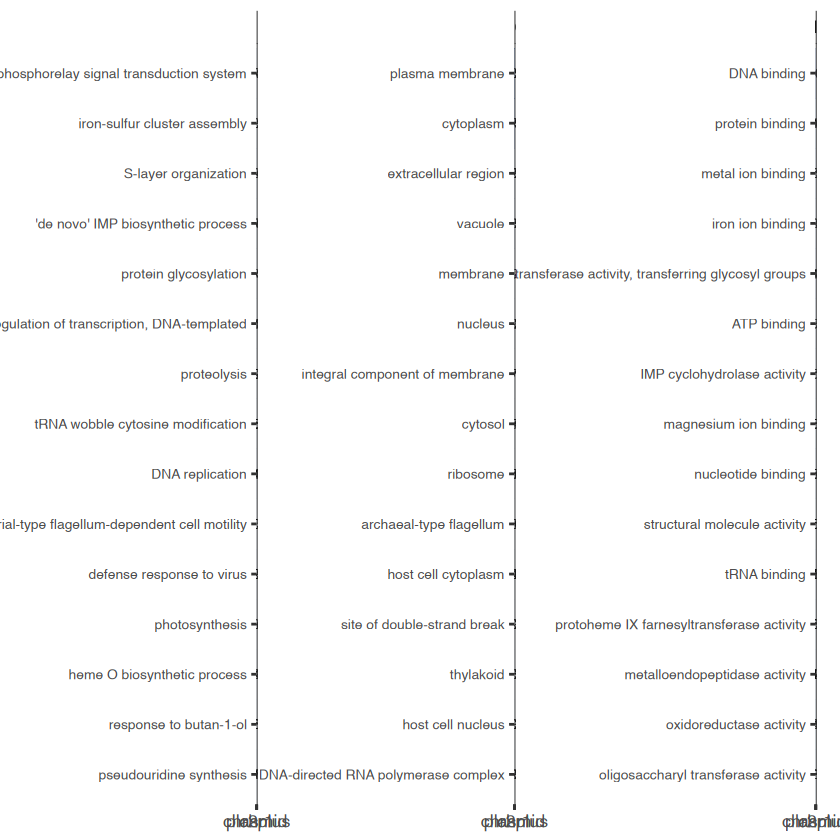

In [10]:
#Recovered functions by replicon
plot_dat <- cluster_consensus %>%
  count(replicon,
    ontology,
    name,
    name = "Clusters") %>%
  group_by(replicon, ontology) %>%
  mutate(Fraction = Clusters / sum(Clusters)) %>%
  ungroup()

#Select the 15 most frequent GO terms within each ontology
top <- plot_dat %>%
  group_by(ontology, name) %>%
  summarise(Total = sum(Clusters),
    .groups = "drop") %>%
  group_by(ontology) %>%
  slice_max(order_by = Total,
    n = 15,
    with_ties = FALSE) %>%
  ungroup()

plot_dat <- plot_dat %>%
  inner_join(top,
    by = c("ontology", "name"))

#Plot
ggplot(plot_dat,
  aes(x = replicon,
    y = fct_reorder(name, Total),
    fill = Fraction)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = Clusters),
    size = 2.8,
    colour = "black") +
  facet_wrap(~ontology,
    scales = "free_y") +
  scale_fill_gradient(low = "#deebf7",
    high = "#08519c",
    name = "Fraction") +
  theme_bw(base_size = 13) +
  labs(x = NULL,
    y = NULL,
    fill = "Fraction") +
  theme(axis.text.y = element_text(size = 8),
    panel.grid = element_blank())
ggsave("./paper/counts_fantasia.svg", width=20)

Saving 20 x 6.67 in image


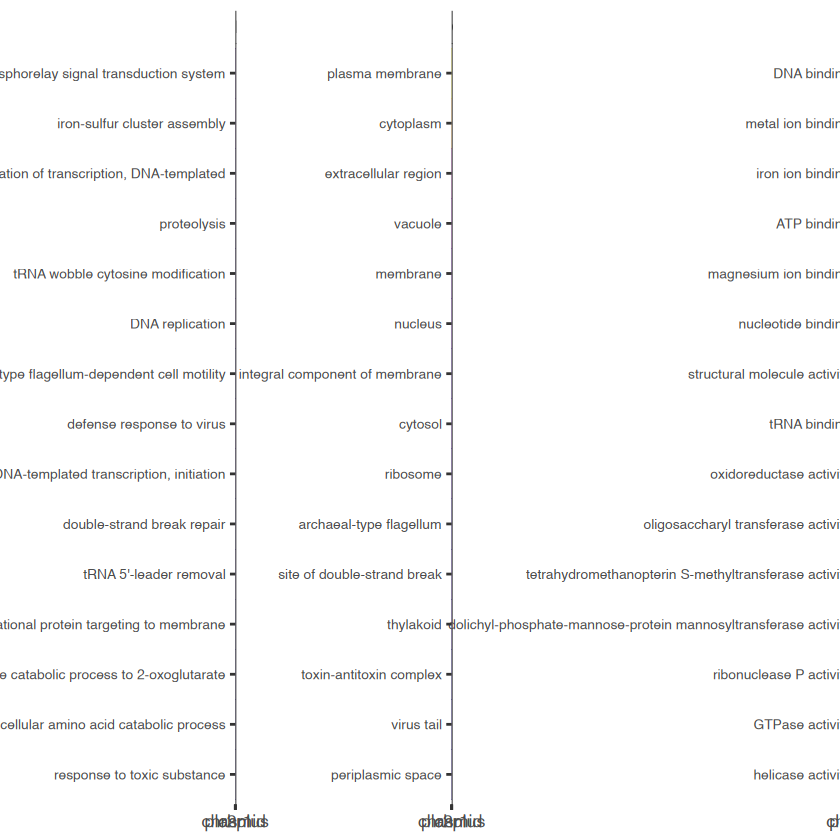

In [14]:
#15 most variable GO terms by replicon
#Count clusters and calculate relative abundance
plot_dat <- cluster_consensus %>%
  count(replicon,
    ontology,
    name,
    name = "Clusters") %>%
  group_by(replicon,
    ontology) %>%
  mutate(Fraction = Clusters / sum(Clusters)) %>%
  ungroup()

#Add missing replicon × ontology × GO combinations as zero
plot_dat <- plot_dat %>%
  complete(replicon,
    ontology,
    name,
    fill = list(
      Clusters = 0,
      Fraction = 0))

#Calculate variability across replicons
top_variable <- plot_dat %>%
  group_by(ontology, name) %>%
  summarise(MaxFraction = max(Fraction),
    MinFraction = min(Fraction),
    Delta = MaxFraction - MinFraction,
    .groups = "drop") %>%
  group_by(ontology) %>%
  slice_max(order_by = Delta,
    n = 15,
    with_ties = FALSE) %>%
  ungroup()

# Keep the 15 most variable GO terms
plot_dat2 <- plot_dat %>%
  inner_join(top_variable,
    by = c("ontology", "name"))

# Order those 15 terms from most to least abundant
plot_dat2 <- plot_dat2 %>%
  group_by(ontology, name) %>%
  mutate(TotalClusters = sum(Clusters)) %>%
  ungroup()

# Plot
ggplot(plot_dat2,
  aes(x = replicon,
    y = fct_reorder(name, TotalClusters),
    fill = Fraction)) +
  geom_tile(color = "white") +
  facet_wrap(~ontology, scales = "free_y") +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Fraction") +
  theme_bw(base_size = 13) +
  labs(x = NULL,
    y = NULL) +
  theme(axis.text.y = element_text(size = 8),
    strip.background = element_rect(fill = "grey95"),
    panel.grid = element_blank())

ggsave("./paper/hm_top15_fantasia.svg", width=20)

Saving 20 x 6.67 in image


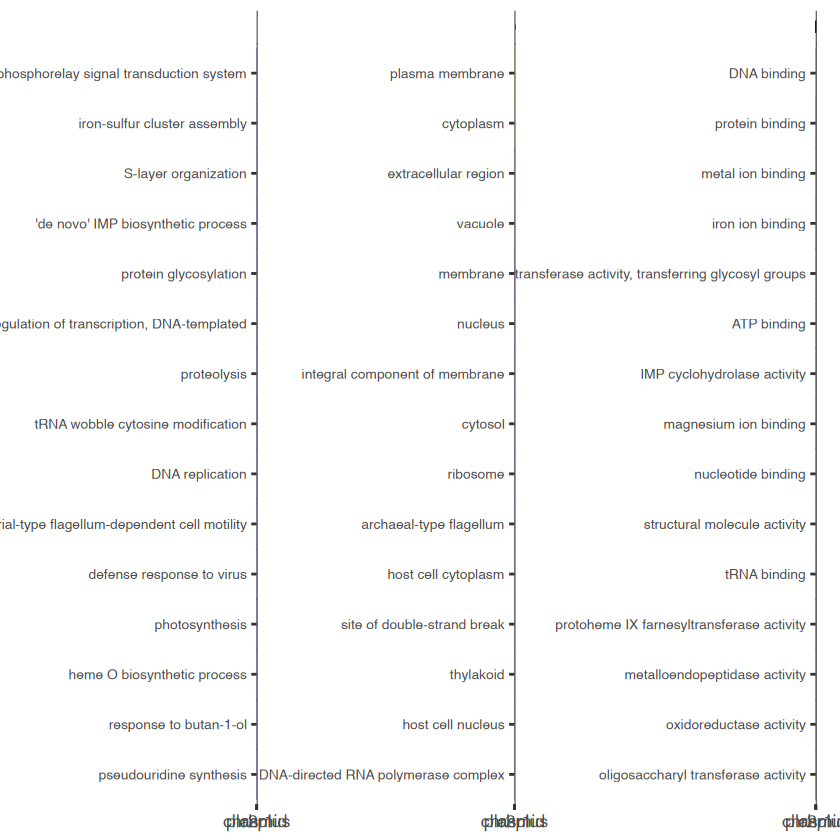

In [12]:
#15 most abundant GO terms by replicon
#Count clusters and calculate relative abundance
plot_dat <- cluster_consensus %>%
  count(replicon,
    ontology,
    name,
    name = "Clusters") %>%
  group_by(replicon,
    ontology) %>%
  mutate(Fraction = Clusters / sum(Clusters)) %>%
  ungroup()

#Add missing replicon × ontology × GO combinations as zero
plot_dat <- plot_dat %>%
  complete(replicon,
    ontology,
    name,
    fill = list(
      Clusters = 0,
      Fraction = 0))

#Calculate total abundance across replicons
top_abundant <- plot_dat %>%
  group_by(ontology,
    name) %>%
  summarise(TotalClusters = sum(Clusters),
    .groups = "drop") %>%
  group_by(ontology) %>%
  slice_max(order_by = TotalClusters,
    n = 15,
    with_ties = FALSE) %>%
  ungroup()

#Keep only the 15 most abundant terms
plot_dat2 <- plot_dat %>%
  inner_join(top_abundant,
    by = c("ontology", "name"))

#Plotting
ggplot(plot_dat2,
  aes(x = replicon,
    y = fct_reorder(name, TotalClusters),
    fill = Fraction)) +
  geom_tile(color = "white") +
  facet_wrap(~ontology,
    scales = "free_y") +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Fraction") +
  theme_bw(base_size = 13) +
  labs(x = NULL,
    y = NULL) +
  theme(axis.text.y = element_text(size = 8),
    strip.background = element_rect(fill = "grey95"),
    panel.grid = element_blank())

ggsave("./paper/hm_top15_abundant_fantasia.svg",width = 20)